# Upset plot

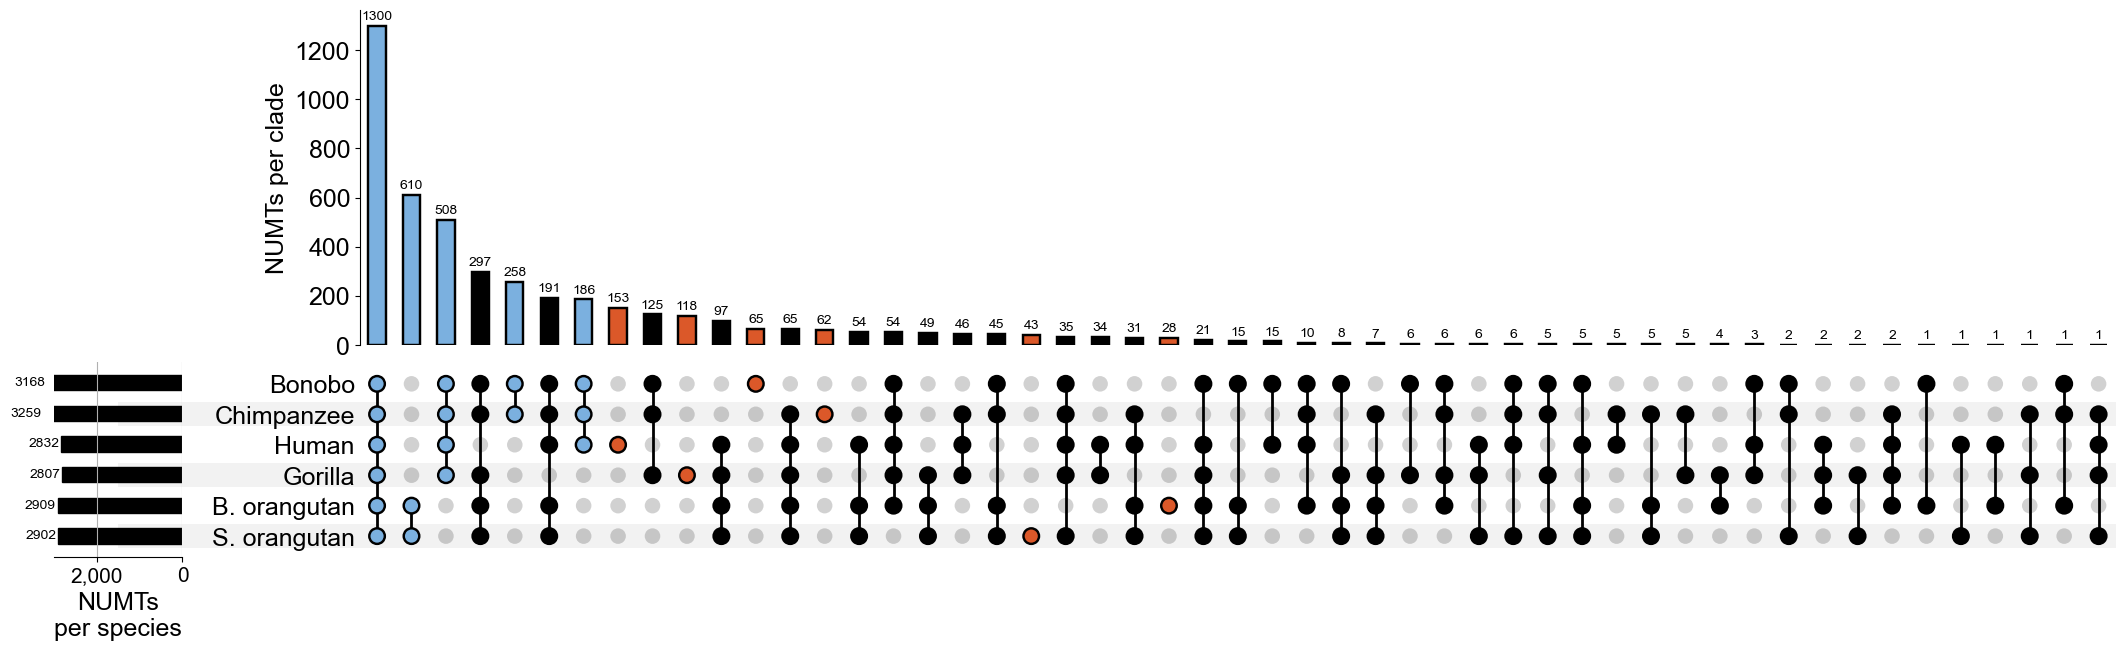

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib.ticker import FuncFormatter, FixedLocator
import upsetplot as upsplt

import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="upsetplot")

def saswat_generate_upset_plot(
        input_file_path,
        output_file_path,
        kmer_dissim_threshold,
        cardinality=False,
        min_subset_size = 1, # Set the minimum subset size
        max_subset_rank = 1000,
        write=False
    ):
    # Load and process the presence/absence matrix.
    presAbs_df = pd.read_table(input_file_path).drop('NUMT', axis=1).rename(columns={'Sorang': "S. orangutan", 'Borang': "B. orangutan"})

    # Reorder columns according to species
    presAbs_df = presAbs_df[["Bonobo", "Chimpanzee", "Human", "Gorilla", "B. orangutan", "S. orangutan"]]

    presAbsMatrixNormUpsetDict = {} #empty dictionary to store the indices of the presence/absence matrix.
    for column in presAbs_df.columns: #iterate through the columns.
        indices = [i for i, value in enumerate(presAbs_df[column]) if value == 1] #store the indices of the column where the value is 1.
        presAbsMatrixNormUpsetDict[column] = indices #store the indices in the dictionary.

    # Import data into the upset plot.
    upsetData = upsplt.from_contents(presAbsMatrixNormUpsetDict) 

    # Filter out subsets that are smaller than the minimum subset size.
    upsetData = upsetData[upsetData >= min_subset_size]

    # Colorblind friendly palette.
    CBPalette = {
        "Black": "#000000", "Orange": "#F4A637", "Light blue": "#B6DBFF", "Vermilion": "#DB5829", "Mid blue": "#7BB0DF",
        "Maroon": "#894B45", "Dark blue": "#1964B0", "Light purple": "#D2BBD7", "Light teal": "#00C992", "Purple": "#AE75A2",
        "Teal": "#008A69", "Dark purple": "#882D71", "Dark teal": "#386350", "Grey": "#DEDEDE", "Yellow": "#E9DC6D"
    }

    # Plot sorting.
    if cardinality:
        sort_by = "cardinality"
    else:
        sort_by = "degree"

    # The real upset plot, however, hidden by making intersection_plot_elements = 0
    upset = upsplt.UpSet(upsetData, sort_by=sort_by, sort_categories_by="-input", facecolor=CBPalette["Black"], 
                        min_subset_size=min_subset_size, max_subset_rank=max_subset_rank, 
                        show_counts=True, totals_plot_elements=4, intersection_plot_elements=10)

    # Optional color customization (excluding Siamang).
    color_0 = CBPalette['Vermilion']
    color_1 = CBPalette['Black']
    color_2 = CBPalette['Mid blue']
    line_width = 1.75
    upset.style_subsets(facecolor=color_1, linewidth=line_width, edgecolor=color_1, present={'Human'} ) # all
    upset.style_subsets(facecolor=color_1, linewidth=line_width, edgecolor=color_1, absent={'Human'} ) # all
    upset.style_subsets(facecolor=color_2, linewidth=line_width, edgecolor=color_1, present={"Bonobo", "Chimpanzee", "Human", "Gorilla", "B. orangutan", "S. orangutan"})  # BCHGO
    upset.style_subsets(facecolor=color_2, linewidth=line_width, edgecolor=color_1, absent={"B. orangutan", "S. orangutan"}, present={"Bonobo", "Chimpanzee", "Human", "Gorilla"})  # BCHG
    upset.style_subsets(facecolor=color_2, linewidth=line_width, edgecolor=color_1, absent={"B. orangutan", "S. orangutan", "Gorilla"}, present={"Bonobo", "Chimpanzee", "Human"})  # BCH
    upset.style_subsets(facecolor=color_2, linewidth=line_width, edgecolor=color_1, absent={"B. orangutan", "S. orangutan", "Gorilla", "Human"}, present={"Bonobo", "Chimpanzee"})  # BC
    upset.style_subsets(facecolor=color_2, linewidth=line_width, edgecolor=color_1, absent={"Gorilla", "Human", "Bonobo", "Chimpanzee"}, present={"B. orangutan", "S. orangutan"})  # O
    upset.style_subsets(facecolor=color_0, linewidth=line_width, edgecolor=color_1, present={'Human'}, absent={"Bonobo", "Chimpanzee", "Gorilla", "B. orangutan", "S. orangutan"} )
    upset.style_subsets(facecolor=color_0, linewidth=line_width, edgecolor=color_1, present={'Gorilla'}, absent={"Bonobo", "Chimpanzee", "Human", "B. orangutan", "S. orangutan"} )
    upset.style_subsets(facecolor=color_0, linewidth=line_width, edgecolor=color_1, present={'Bonobo'}, absent={"Chimpanzee", "Human", "Gorilla", "B. orangutan", "S. orangutan"} )
    upset.style_subsets(facecolor=color_0, linewidth=line_width, edgecolor=color_1, present={'Chimpanzee'}, absent={"Bonobo", "Human", "Gorilla", "B. orangutan", "S. orangutan"} )
    upset.style_subsets(facecolor=color_0, linewidth=line_width, edgecolor=color_1, present={'S. orangutan'}, absent={"Bonobo", "Chimpanzee", "Human", "Gorilla", "B. orangutan"} )
    upset.style_subsets(facecolor=color_0, linewidth=line_width, edgecolor=color_1, present={'B. orangutan'}, absent={"Bonobo", "Chimpanzee", "Human", "Gorilla", "S. orangutan"} )

    # Plot configurations
    # rcParams["font.size"] = 6.5
    rcParams['font.family'] = 'Arial'

    # UPSET PLOT the result.
    plot_result = upset.plot()

    # Set the font size of the y-axis tick labels.
    plot_result["matrix"].tick_params(axis='y', labelsize=18) # Species names

    # Define the formatter function.
    def comma_formatter(x, pos):
        return '{:,.0f}'.format(x)

    # The totals horizontal section.
    plot_result["totals"].xaxis.set_major_formatter(FuncFormatter(comma_formatter))
    plot_result["totals"].set_xlabel("NUMTs\nper species", fontsize=18, x=0.5) #set the x label
    plot_result["totals"].tick_params(labelsize=15) #set the x tick labels
    
    # Adjust the position of the totals plot to shift it more to the left.
    plot_result["totals"].set_position([0.1, 0.11, 0.05, 0.275]) # x, y, width, height
    plot_result["totals"].set_xlim(3000, 0)

    if max_subset_rank < 100:
         # Adjust the position of the totals plot to shift it more to the left.
        plot_result["totals"].set_position([0.12, 0.11, 0.05, 0.275])
        plot_result["totals"].set_xlim(3000, 0)
        plot_result["totals"].set_xlabel("NUMTs\nper species", fontsize=15, x=0.65) #set the x label

    # plt.title(f"Number of NUMTs shared among species\n",fontsize=25)
    plt.ylabel("NUMTs per clade", fontsize=18) 
    plt.yticks(fontsize=18) 
    plt.grid(alpha=0.0, linestyle="--")
    plt.savefig(output_file_path, format=output_file_path[-3:], transparent=True) #save the plot

    plt.show()



#######
# Run:
#######

flanks=500
kmer_dissim_threshold=0.5
file_in = f"results_{flanks}bp/species_matrix_flanks{flanks}_{kmer_dissim_threshold}.tsv"
file_out = f"results_{flanks}bp/upset_plot_flanks{flanks}_{kmer_dissim_threshold}_cardinality.pdf"

saswat_generate_upset_plot(
    input_file_path=file_in,
    output_file_path=file_out,
    kmer_dissim_threshold=kmer_dissim_threshold,
    min_subset_size=1,
    max_subset_rank = 1000,
    cardinality=True,
    write=True
)

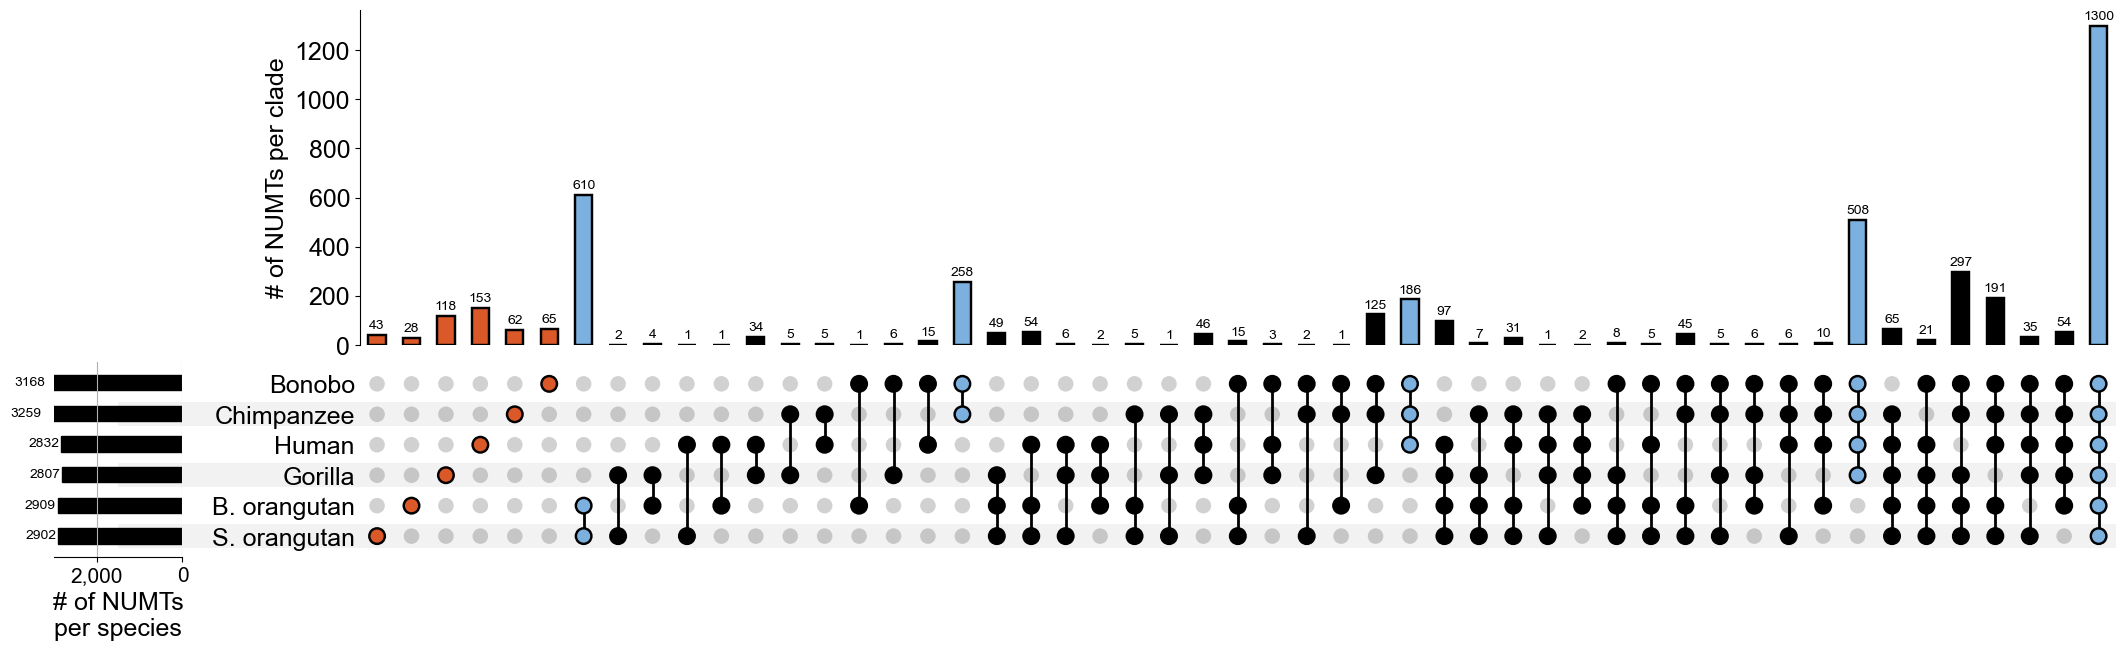

In [ ]:
file_out = f"results_{flanks}bp/upset_plot_flanks{flanks}_{kmer_dissim_threshold}.pdf"
saswat_generate_upset_plot(
    input_file_path=file_in,
    output_file_path=file_out,
    kmer_dissim_threshold=kmer_dissim_threshold,
    min_subset_size=1,
    max_subset_rank=1000,
    cardinality=False,
    write=True
)


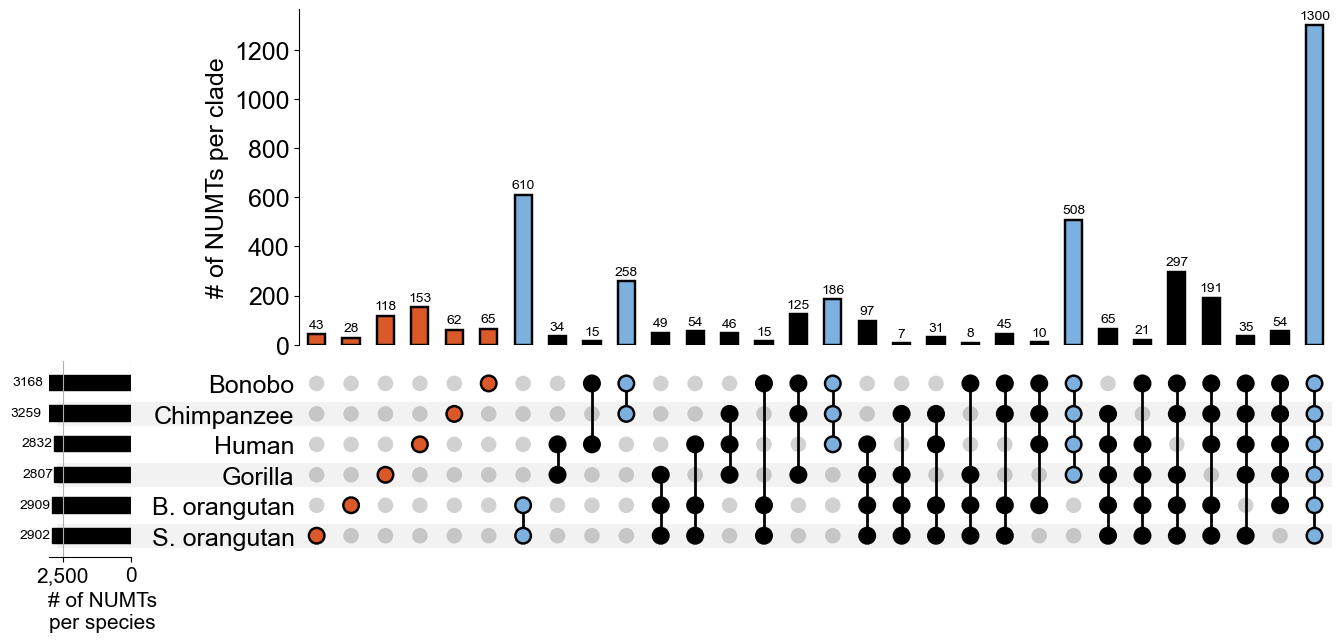

In [ ]:
# Top 30 clades.

file_out = f"upset_plot_flanks{flanks}_{kmer_dissim_threshold}_max30.pdf"
saswat_generate_upset_plot(
    input_file_path=file_in,
    output_file_path=file_out,
    kmer_dissim_threshold=kmer_dissim_threshold,
    min_subset_size=1,
    max_subset_rank=30,
    cardinality=False,
    write=True
)

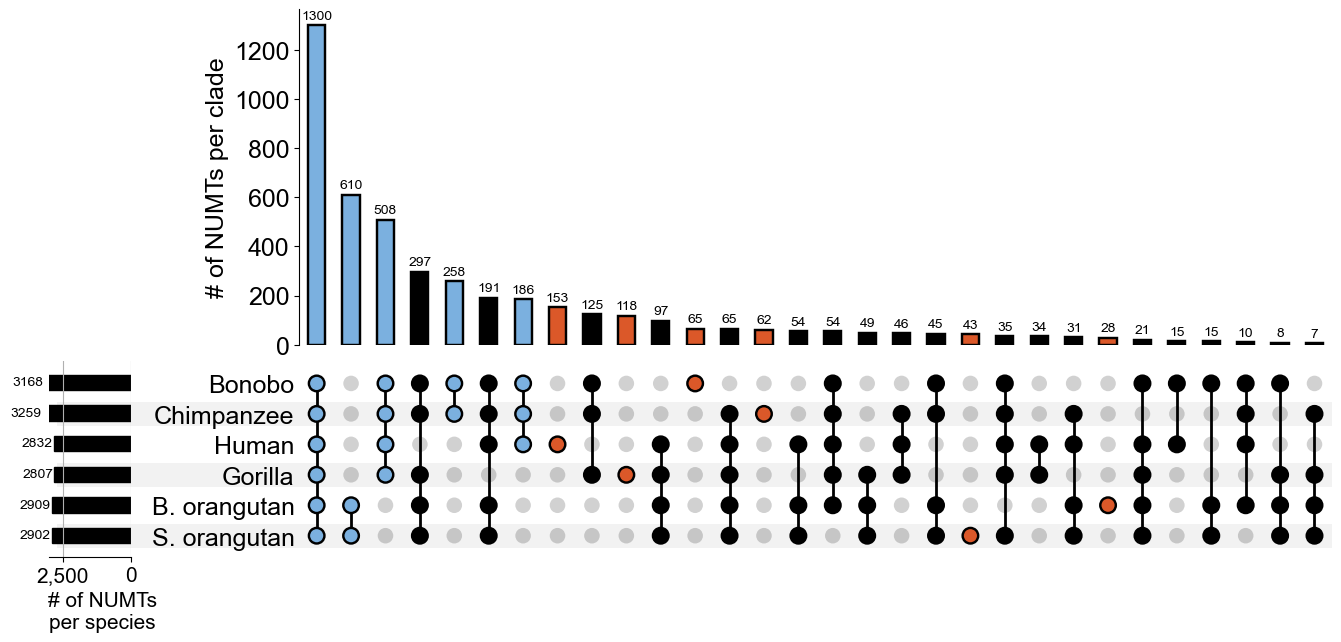

In [ ]:
# Top 30 clades.

file_out = f"upset_plot_flanks{flanks}_{kmer_dissim_threshold}_max30_cardinality.pdf"
saswat_generate_upset_plot(
    input_file_path=file_in,
    output_file_path=file_out,
    kmer_dissim_threshold=kmer_dissim_threshold,
    min_subset_size=1,
    max_subset_rank=30,
    cardinality=True,
    write=True
)

# Older upset plot code

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="upsetplot")

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib.ticker import FuncFormatter, FixedLocator
import upsetplot as upsplt


def generate_upset_plot(input_file_path,        output_file_path,
                        kmer_dissim_threshold,  freq_threshold=0, write=False):
    # Load and process the presence/absence matrix
    presAbs_df = pd.read_table(input_file_path).drop('NUMT', axis=1).rename(columns={'Sorang': "S. orangutan", 'Borang': "B. orangutan"})

    # Reorder columns according to species
    presAbs_df = presAbs_df[["Bonobo", "Chimpanzee", "Human", "Gorilla", "S. orangutan", "B. orangutan", "Siamang"]]

    # Create a dictionary to store the indices of presence/absence matrix
    presAbsMatrixNormUpsetDict = {}
    for column in presAbs_df.columns:
        indices = presAbs_df.index[presAbs_df[column] == 1].tolist()
        presAbsMatrixNormUpsetDict[column] = indices

    # Generate upset plot data
    upsetData = upsplt.from_contents(presAbsMatrixNormUpsetDict)

    # Plot configurations
    rcParams["font.size"] = 6.5
    rcParams['font.family'] = 'Arial'

    upset = upsplt.UpSet(upsetData, sort_categories_by="-input", facecolor="#000",
                         min_subset_size=freq_threshold, show_counts=False,
                         totals_plot_elements=4, intersection_plot_elements=10)

    # Optional color customization
    colorhex = ["#004d71", "#8759a1", "#f75a78", "#ffa600"]
    upset.style_subsets(facecolor=colorhex[0], linewidth=1, absent={"Siamang"}, present={"Bonobo", "Chimpanzee", "Human", "Gorilla", "S. orangutan", "B. orangutan"})  # BCHGO
    upset.style_subsets(facecolor=colorhex[0], linewidth=1, absent={"Siamang", "S. orangutan", "B. orangutan"}, present={"Bonobo", "Chimpanzee", "Human", "Gorilla"})  # BCHG
    upset.style_subsets(facecolor=colorhex[0], linewidth=1, absent={"Siamang", "S. orangutan", "B. orangutan", "Gorilla"}, present={"Bonobo", "Chimpanzee", "Human"})  # BCH
    upset.style_subsets(facecolor=colorhex[0], linewidth=1, absent={"Siamang", "S. orangutan", "B. orangutan", "Gorilla", "Human"}, present={"Bonobo", "Chimpanzee"})  # BC
    upset.style_subsets(facecolor=colorhex[0], linewidth=1, absent={"Siamang", "Gorilla", "Human", "Bonobo", "Chimpanzee"}, present={"S. orangutan", "B. orangutan"})  # O

    # Plot the upset plot
    plot_result = upset.plot()

    # Formatter function for y-axis and x-axis
    def comma_formatter(x, pos):
        return '{:,.0f}'.format(x)

    plot_result["intersections"].yaxis.set_major_formatter(FuncFormatter(comma_formatter))
    plt.yticks(size=12)

    # Setting y-tick labels for the matrix plot
    matrix_yticks = plot_result["matrix"].get_yticks()
    plot_result["matrix"].yaxis.set_major_locator(FixedLocator(matrix_yticks))
    plot_result["matrix"].set_yticklabels(plot_result["matrix"].get_yticklabels(), fontsize=12)

    # Setting x-tick labels for the totals plot
    xticks = plot_result["totals"].get_xticks()
    plot_result["totals"].xaxis.set_major_locator(FixedLocator(xticks))
    plot_result["totals"].xaxis.set_major_formatter(FuncFormatter(comma_formatter))
    plot_result["totals"].set_xlabel("Total number of NUMTs \nin species", fontsize=12)
    plot_result["totals"].set_xticklabels([f"{int(tick):,}" for tick in xticks], fontsize=8)
    plt.xticks(size=12)

    # Plot title and additional configurations
    freq_in_title = f', freq ≥ {freq_threshold}' if freq_threshold != 0 else ''
    kmer_in_title = f'(k-mer dissimilarity ≤ {kmer_dissim_threshold}{freq_in_title})'
    plt.title(f"Number of NUMTs shared among species {kmer_in_title} \n", fontsize=18)
    plt.ylabel("Number of NUMTs", fontsize=12)
    plt.grid(alpha=0.5, linestyle="--")
    
    if write:
        # Save figure
        figure_type = output_file_path.split('.')[-1]
        plt.savefig(output_file_path, format=figure_type, transparent=True)
        figure_type2 = 'png' if figure_type != 'png' else 'pdf'
        output_file_path_2 = f"{''.join(output_file_path.split('.')[:-2])}.{output_file_path.split('.')[-2]}.{figure_type2}"
        plt.savefig(output_file_path_2, format=figure_type2, transparent=True)

    # Show the plot
    plt.show()


# Example usage:

# kmer_dissim_threshold = 0.5
# generate_upset_plot(input_file_path=f"kmer_test/species_matrix_{kmer_dissim_threshold}.tsv",
#                     output_file_path=f"kmer_test/upset_plot_{kmer_dissim_threshold}.pdf",
#                     freq_threshold=0, 
#                     kmer_dissim_threshold=kmer_dissim_threshold)

def run_generate_upset_plot( flanks=500, list_kd=[ 0.2, 0.5, 0.8 ], freq=0, write=True ):
    '''
    Generates an upset plot for each condition.
    Input:
    - List of K-mer dissimilarity scores (e.g.).
    - Frequency threshold of histogram (e.g. at least 5 counts).
    '''
    print(f"{flanks}bp flanks")
    for kmer_dissim_threshold in list_kd:
        freq_in_file_out = f"_{freq}" if freq != 0 else ''
        # # Old pipeline using 500 bp:
        # file_in = f"../kmer_test/species_matrix_{kmer_dissim_threshold}.tsv"
        # file_out = f"../kmer_test/upset_plot_{kmer_dissim_threshold}.pdf"
        # Longer flanks pipeline:
        #file_in = f"results_{flanks}bp/species_matrix_{kmer_dissim_threshold}.flanks{flanks}.tsv"
        file_in = f"results_{flanks}bp/species_matrix_flanks{flanks}_{kmer_dissim_threshold}.tsv"
        file_out = f"results_{flanks}bp/upset_plot_flanks{flanks}_{kmer_dissim_threshold}.pdf"

        generate_upset_plot(input_file_path=file_in,
                        output_file_path=file_out,
                        freq_threshold=freq, 
                        kmer_dissim_threshold=kmer_dissim_threshold,
                        write=False
        )
        
run_generate_upset_plot( flanks=500 )



500bp flanks


KeyError: "['Siamang'] not in index"

## 500 bp flanks (freq≥5)

500bp flanks


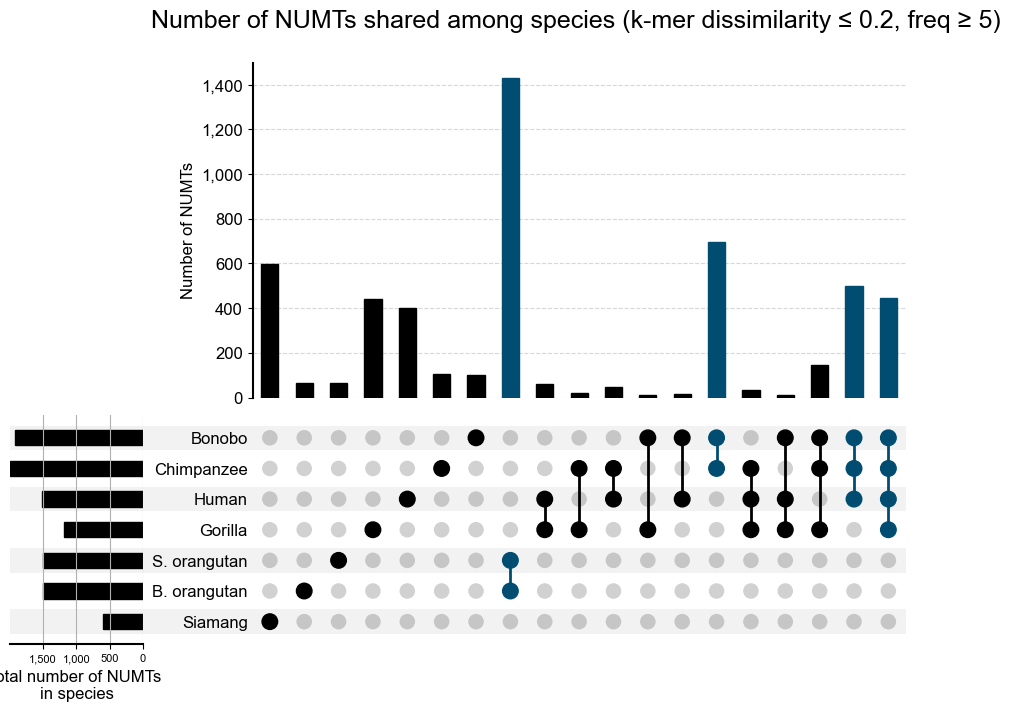

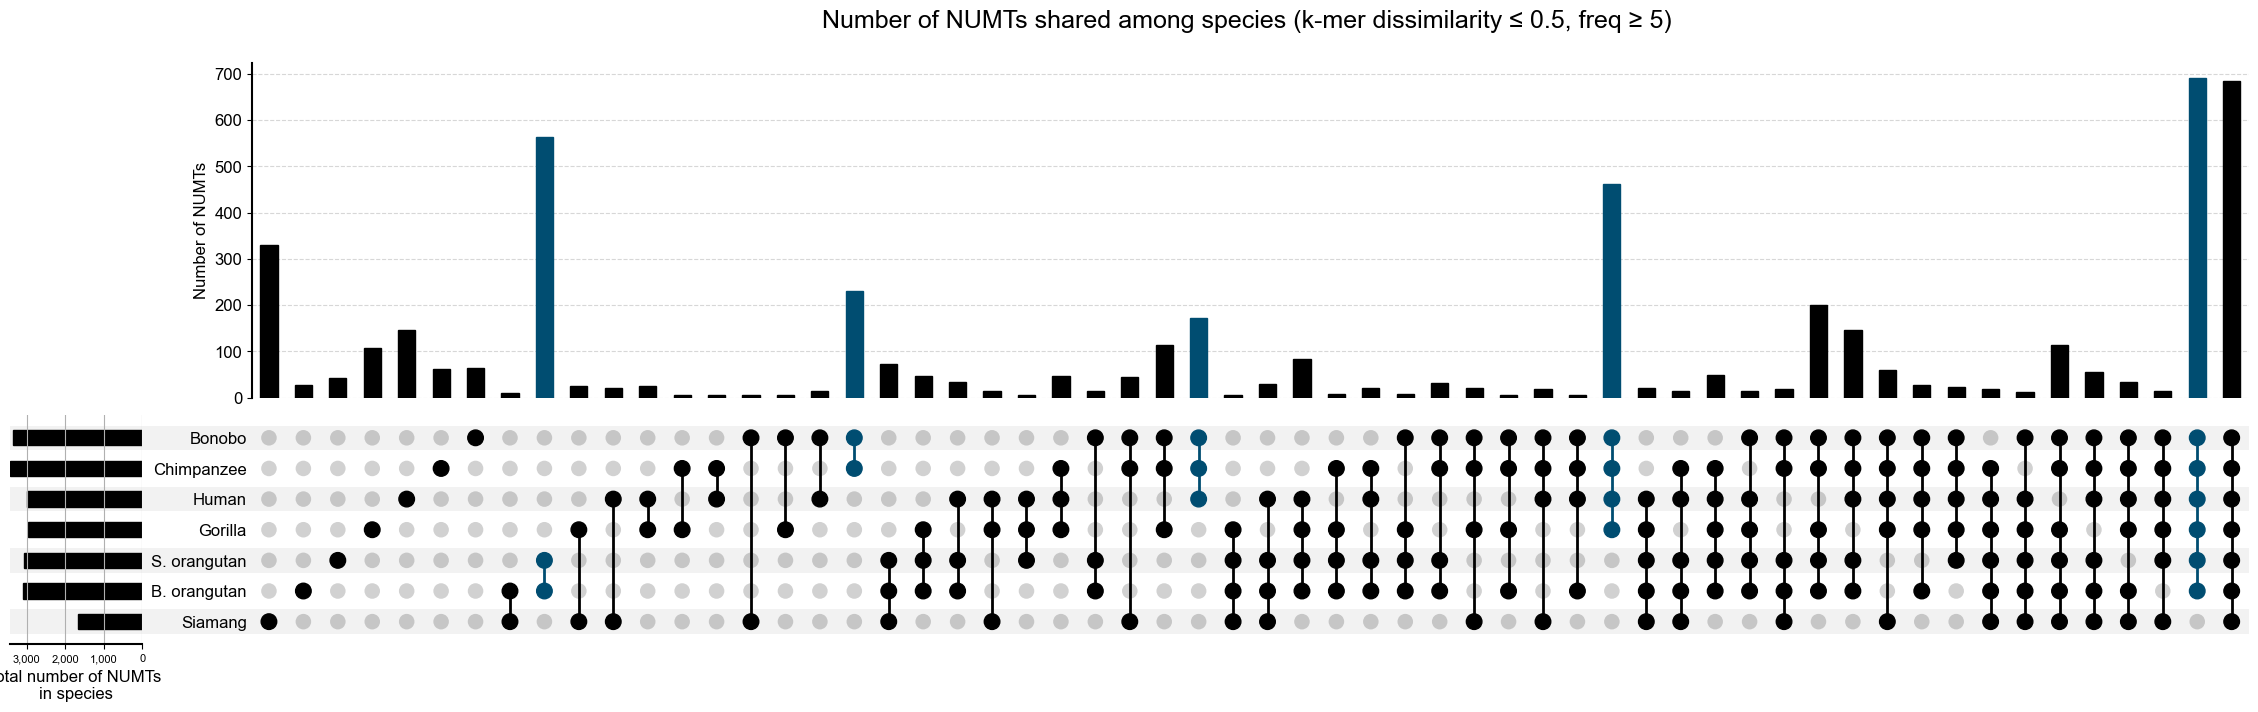

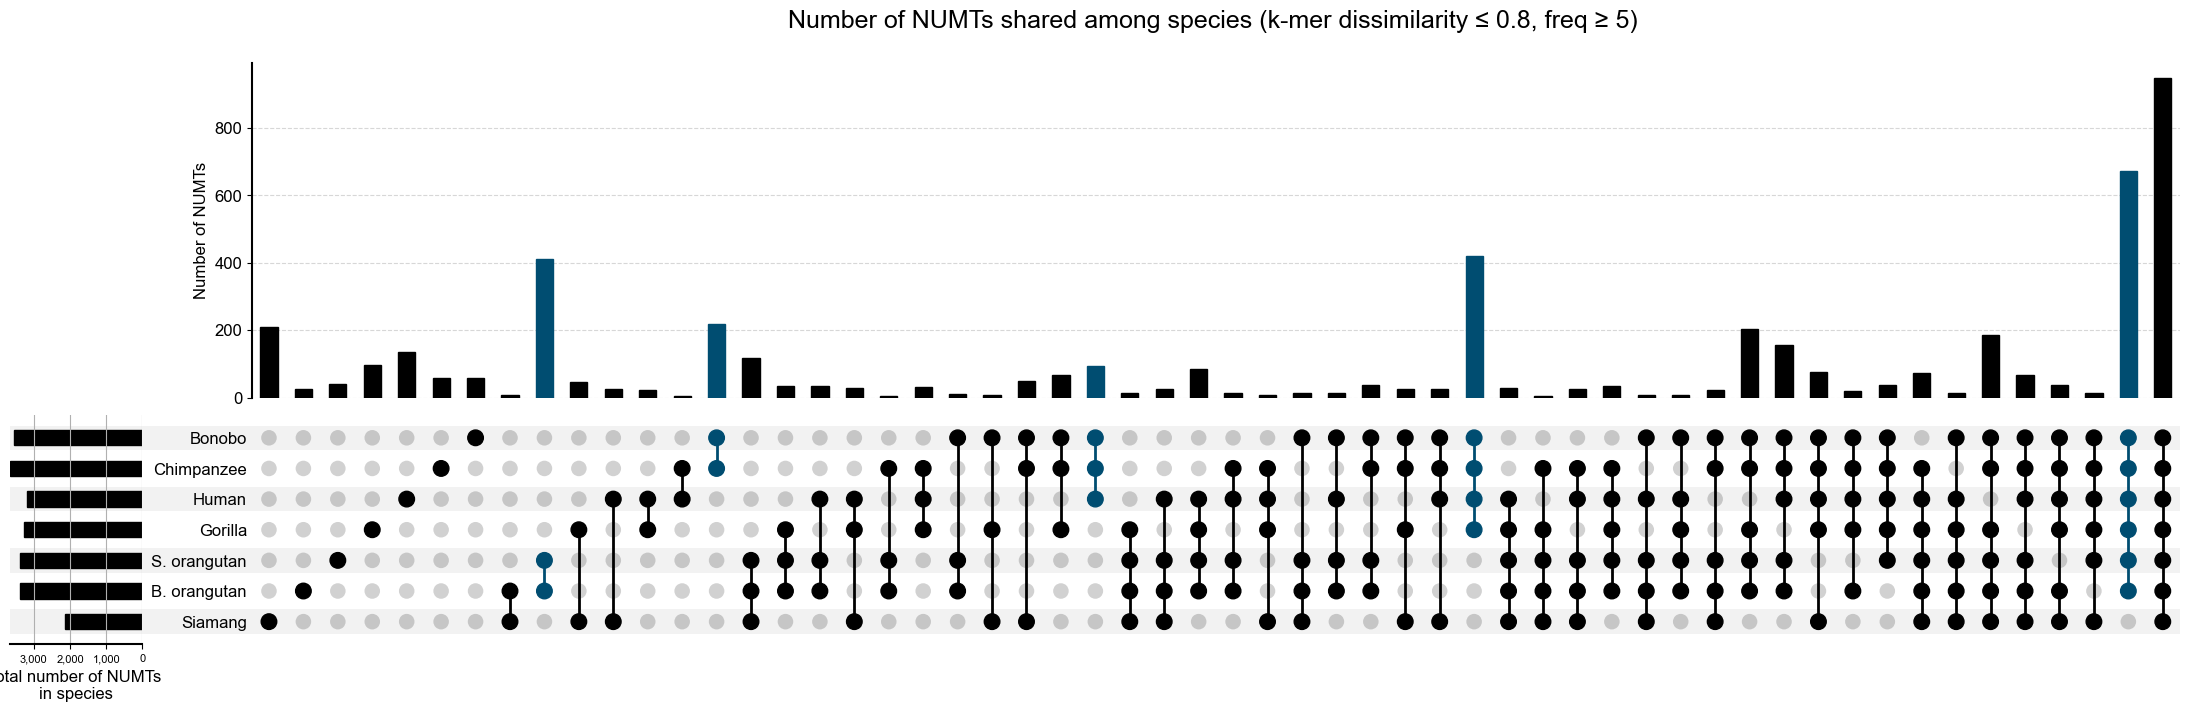

In [ ]:
run_generate_upset_plot( flanks=500, freq=5, write=False )

## 600 bp flanks

600bp flanks


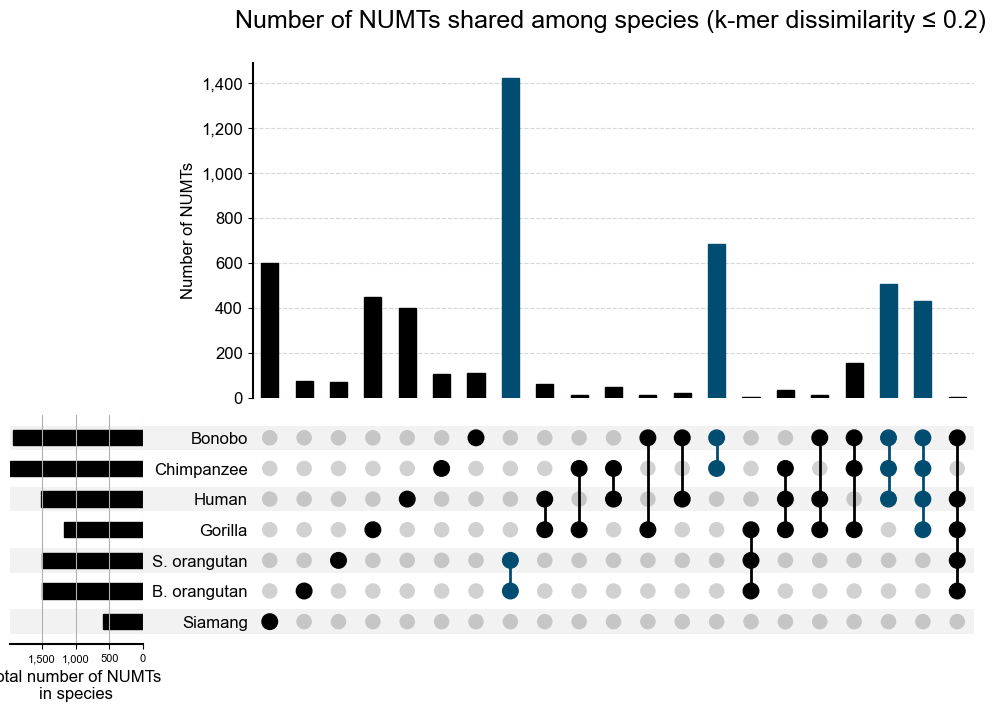

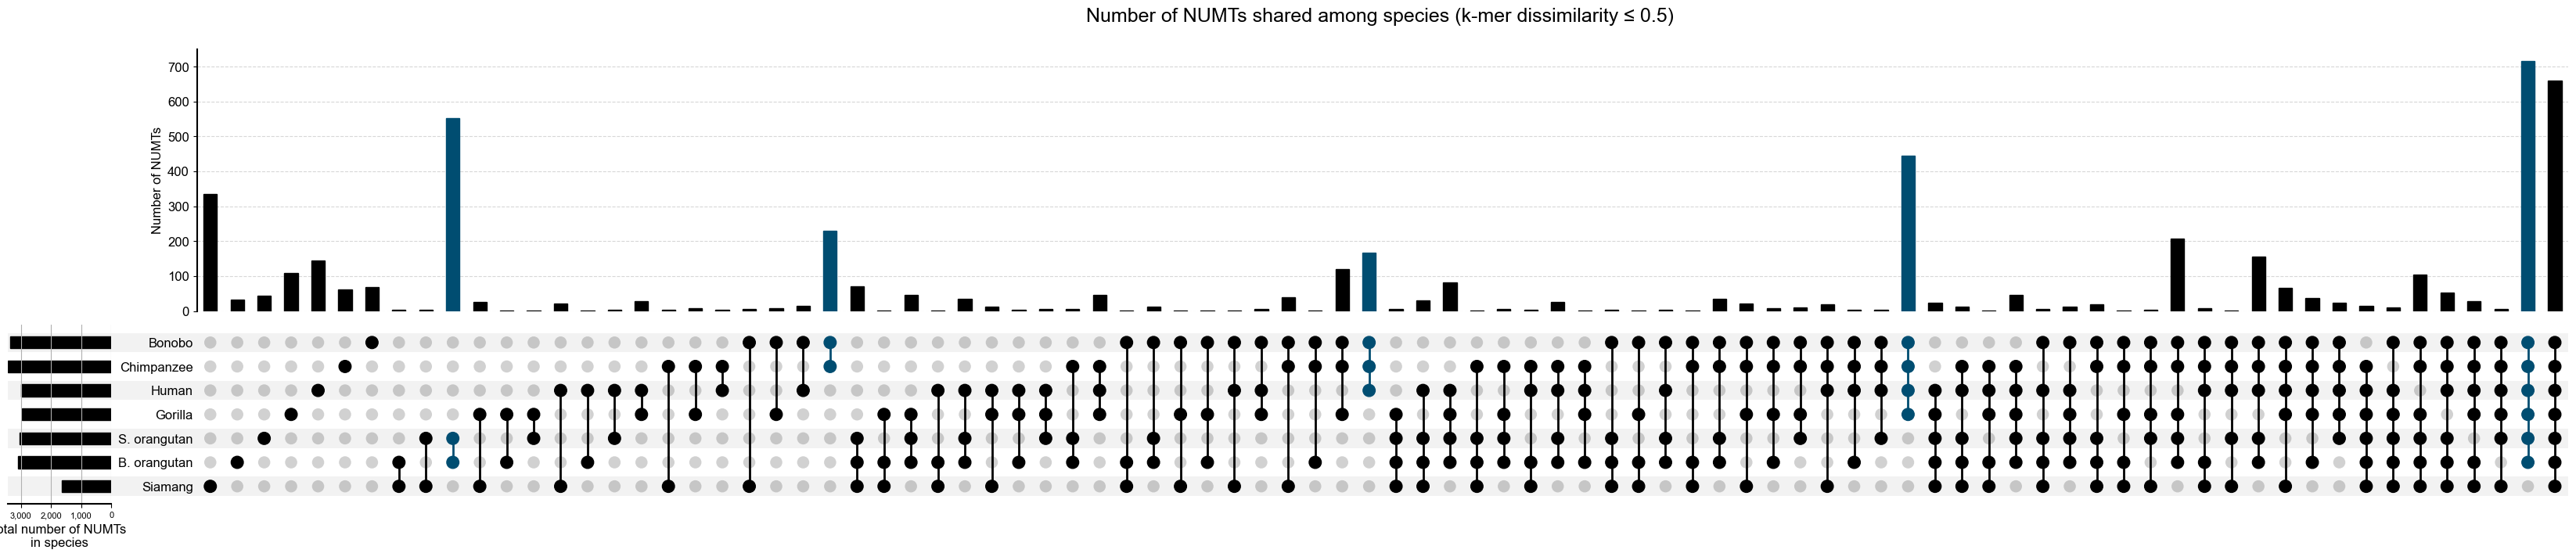

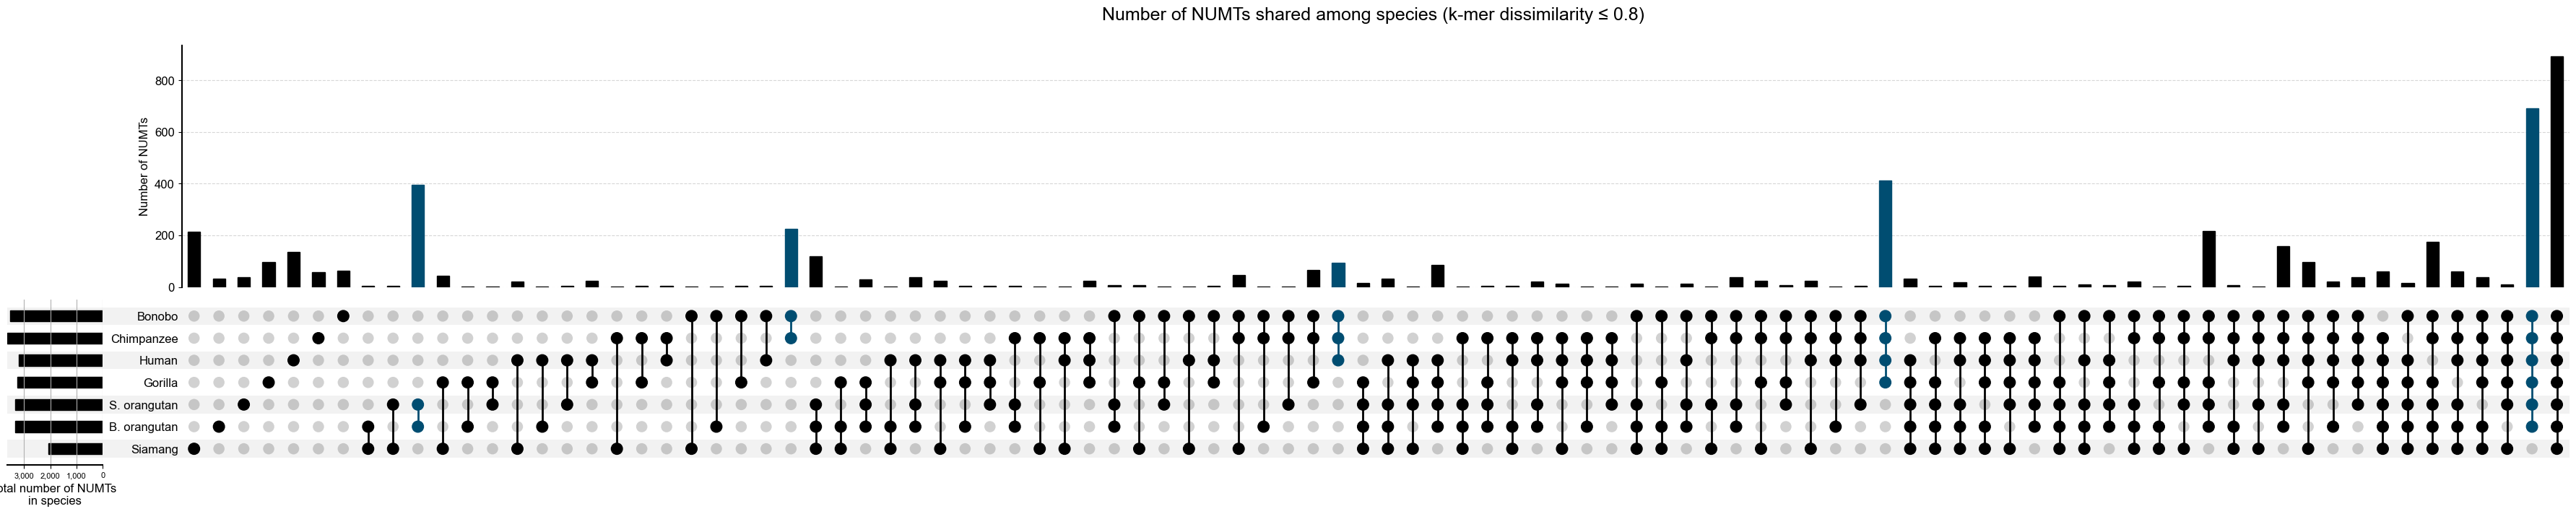

In [ ]:
run_generate_upset_plot( flanks=600 )

## 750 bp flanks

750bp flanks


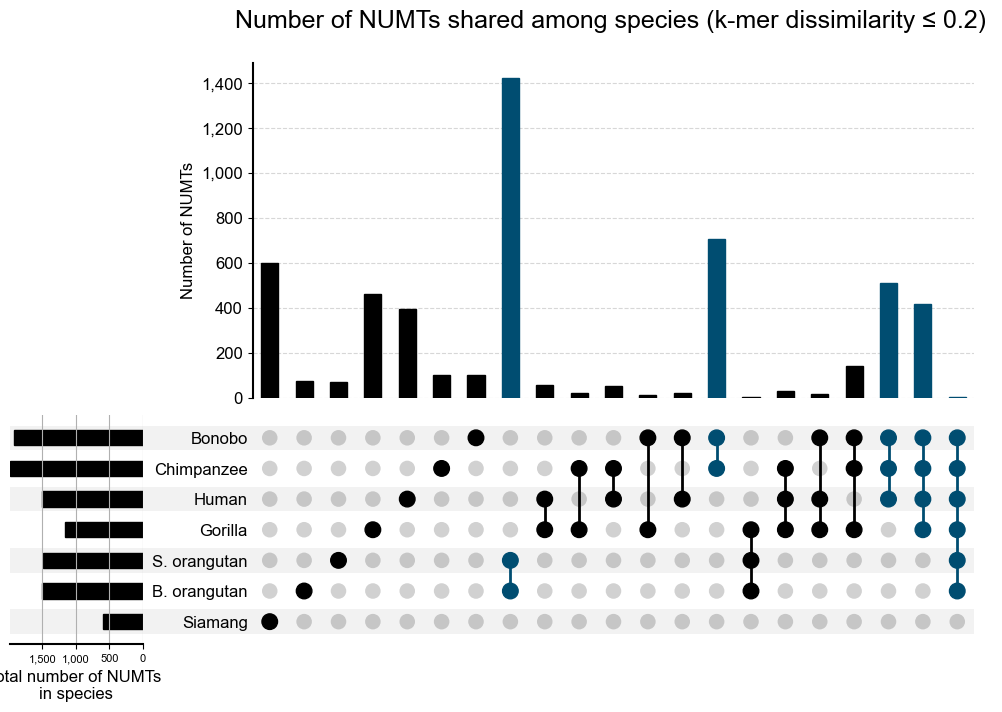

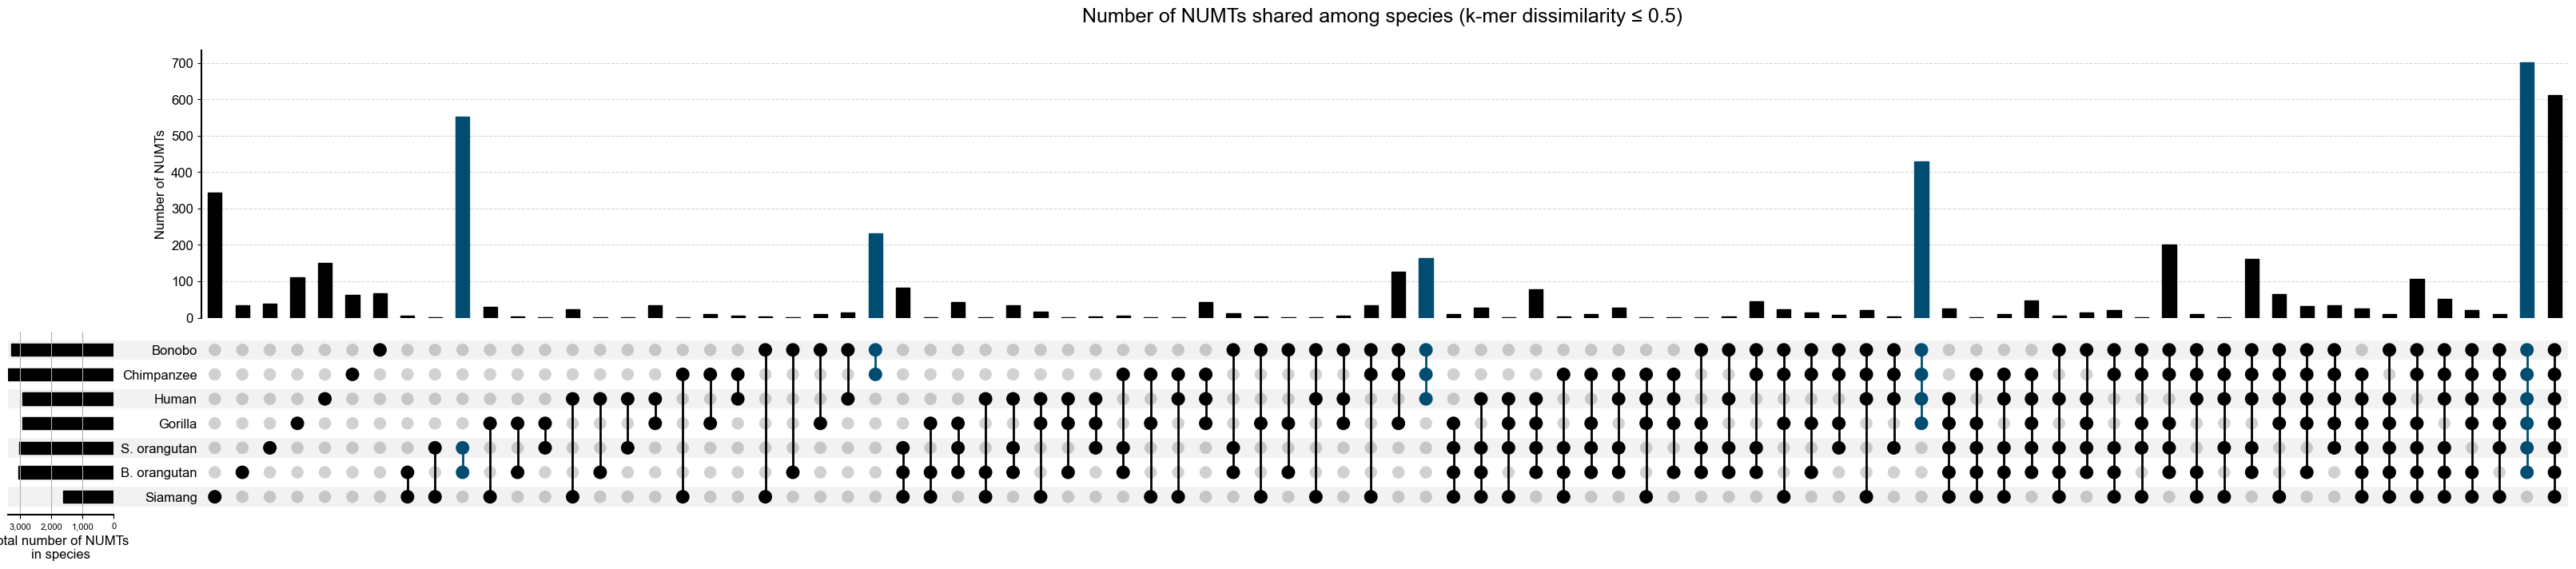

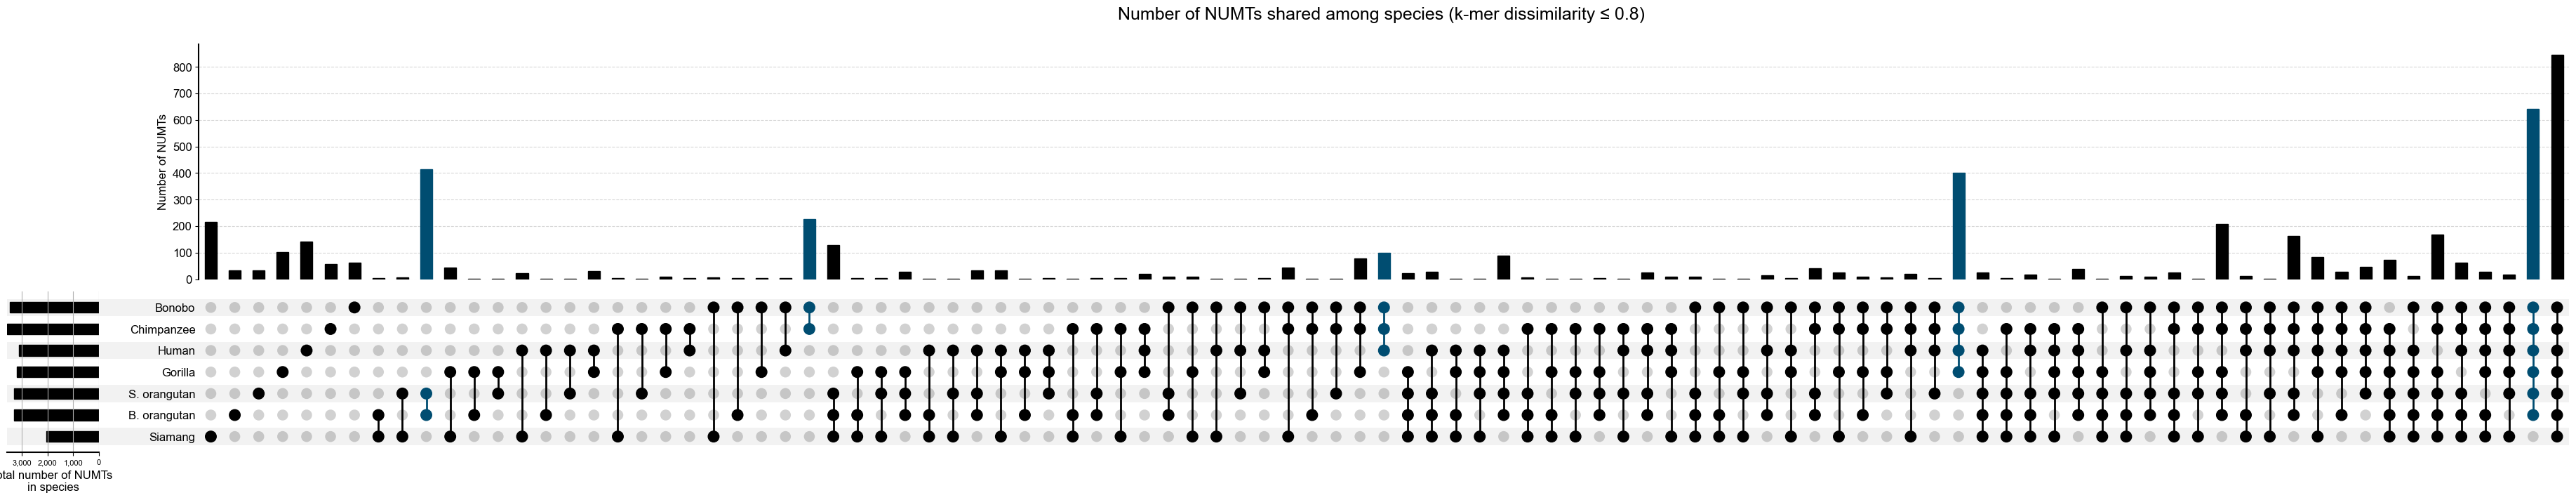

In [ ]:
run_generate_upset_plot( flanks=750 )

## 1000 bp flanks

1000bp flanks


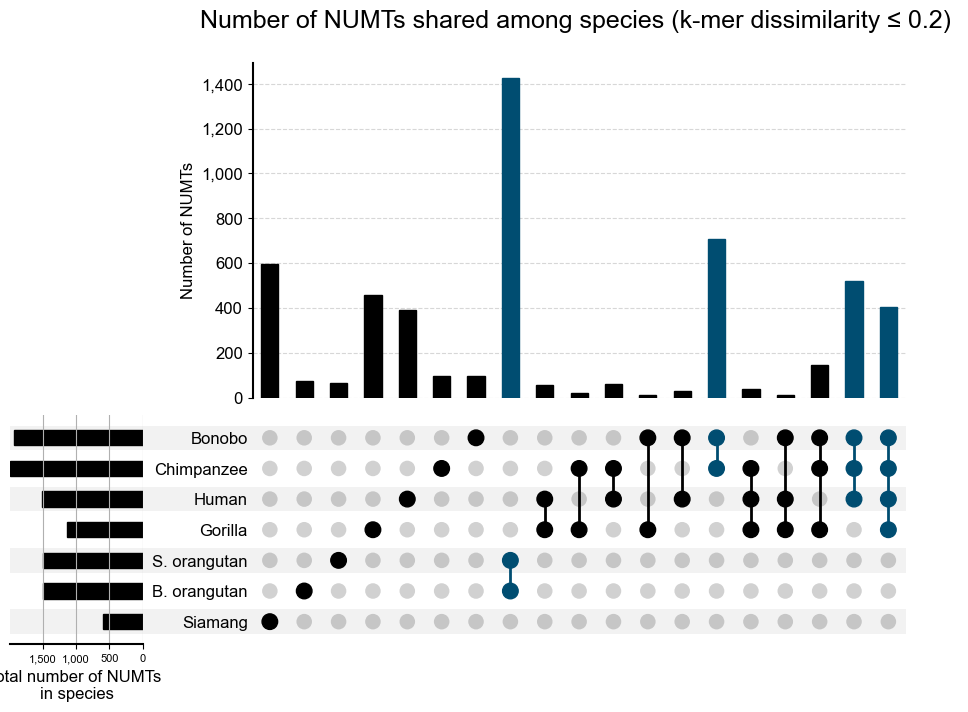

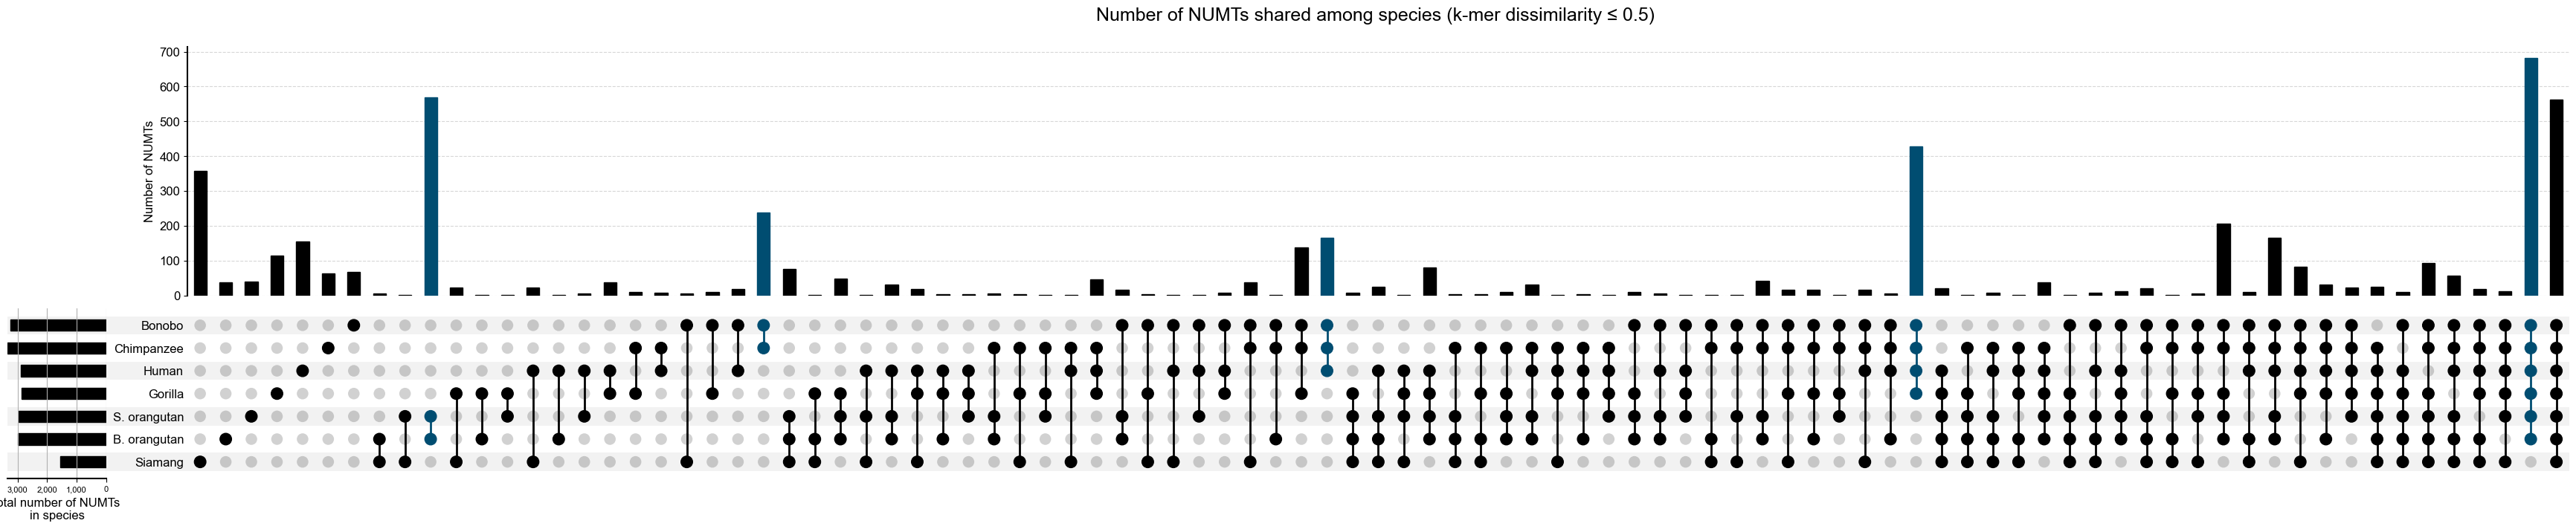

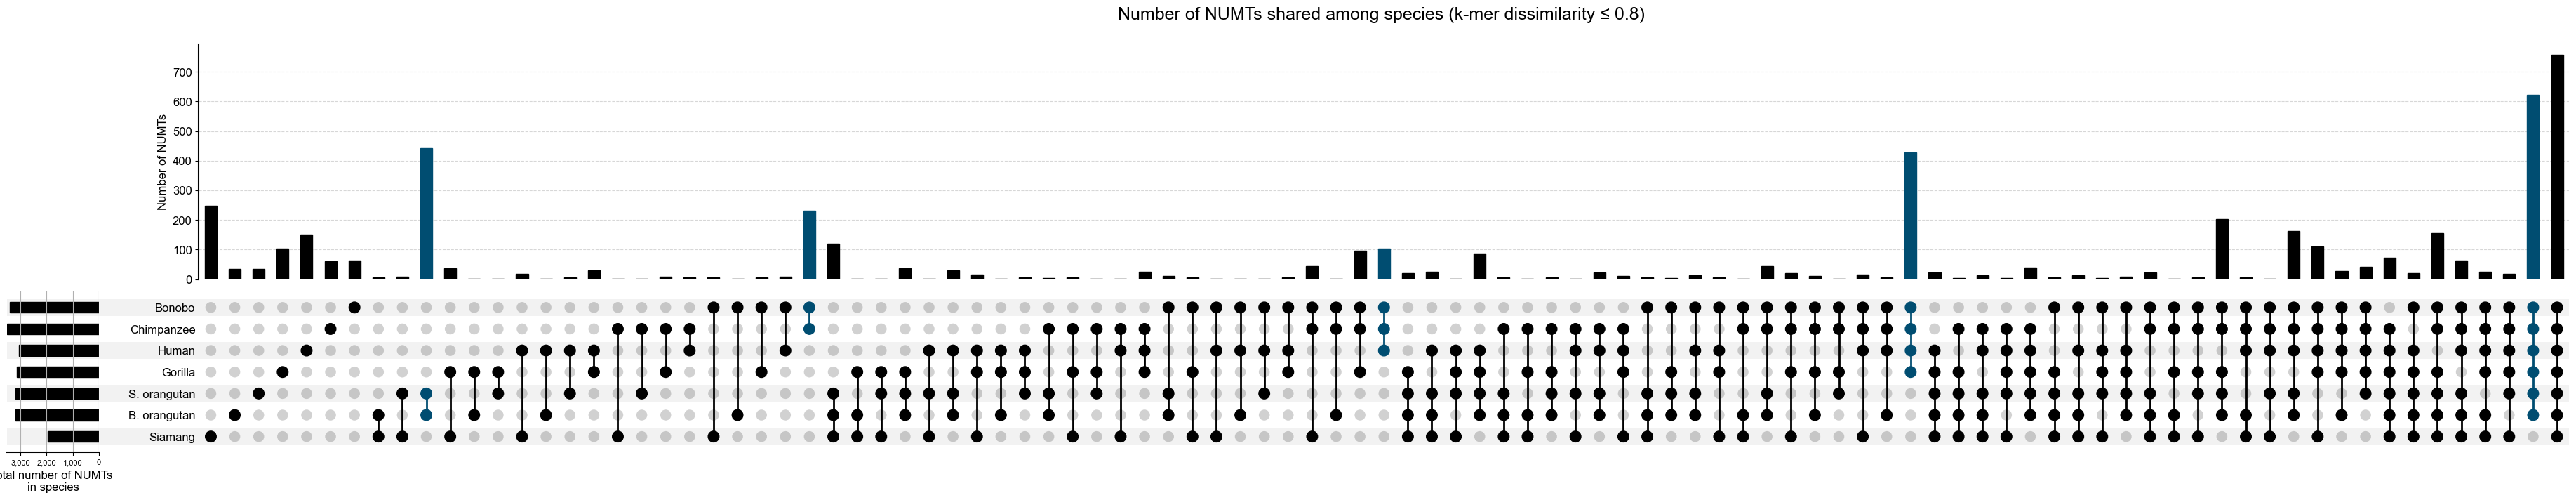

In [ ]:
run_generate_upset_plot( flanks=1000 )